### [ 데이터 분포 시각화 및 형태 확인]
- 분포 시각화 : 히스토그램
- 형태 수치화 : 왜도(skew), 첨도(kurt) - 뾰족함 정도

[1] 데이터 분포 확인 및 시각화 <hr>

In [2]:
## =====================================
## 모듈 로딩
## =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from scipy.stats import skew, kurtosis

In [3]:
## ===========================================
## 예제데이터 만들기
## ===========================================
## 데이터 재현성 설정
np.random.seed(42)

## 표준 정규 분포(평균 0, 표준편차 1)에 가까운 예제 데이터 1000개
data_normal = np.random.normal(loc=0, scale=1, size=1000)

## 오른쪽으로 긴 꼬리를 가진 치우친 데이터 (지수부포)
data_skewed = np.random.exponential(scale=1, size=1000)

## pandas Series로 변환
nSR = pd.Series(data_normal, name='normal')
sSR = pd.Series(data_skewed, name='skewed')




In [4]:
def print_stats(series) :
    ## ndarray 타입
    x = series.values
    
    ##  평균, 표준편차(ddof=1 불편분산, 표본 데이터이기 때문)
    mean = x.mean()
    std = x.std()
    
    ## 왜도 (skewness) : 비대칭 정도
    sk = skew(x,bias = False)
    
    ## 첨도 : 뾰족 정도 => 이상치 체크
    ku = kurtosis(x,fisher=True, bias=False)
    
    print(f' ==== {series.name} 데이터 통계 ====')
    print(f'개   수 : {len(x)}')
    print(f'평   균 : {mean}')
    print(f'표준편차 : {std}')
    print(f'왜   도 : {sk}')
    print(f'첨   도 : {ku}')
    print()
print_stats(nSR)
print_stats(sSR)


 ==== normal 데이터 통계 ====
개   수 : 1000
평   균 : 0.01933205582232549
표준편차 : 0.9787262077473543
왜   도 : 0.11697636882001397
첨   도 : 0.07256220235414768

 ==== skewed 데이터 통계 ====
개   수 : 1000
평   균 : 1.0079859336968675
표준편차 : 1.0024868892945484
왜   도 : 1.9837888698617543
첨   도 : 5.412458925830524



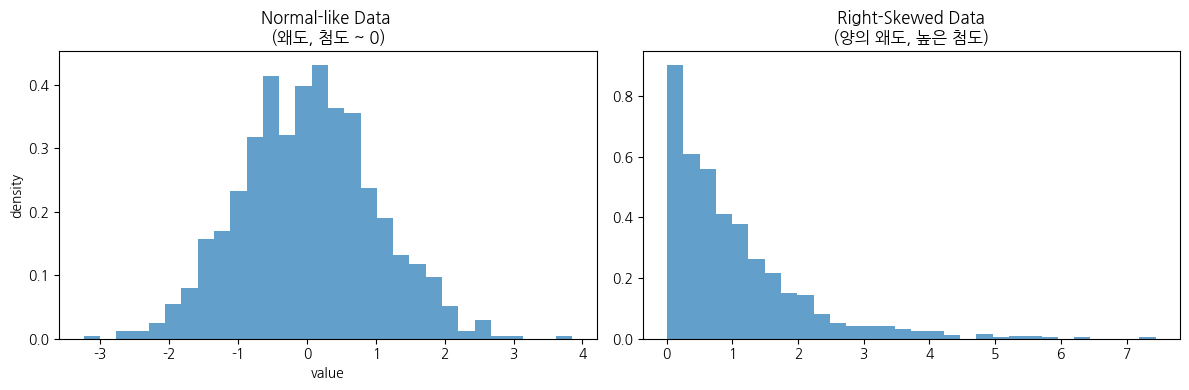

In [ ]:
## ====================================================
## 데이터 분포 시각화 - 히스토그램
## ====================================================
fig, axes = plt.subplots(1,2,figsize = (12,4))

## 정규분포 데이터 히스토그램
axes[0].hist(nSR, bins=30, density=True, alpha=0.7)
axes[0].set_title('Normal-like Data \n(왜도, 첨도 ~ 0)')
axes[0].set_xlabel('value')
axes[0].set_ylabel('density')

## 치우친 데이터 히스토그램
axes[1].hist(sSR, bins=30, density=True, alpha=0.7)
axes[1].set_title('Right-Skewed Data\n(양의 왜도, 높은 첨도)')
axes[0].set_xlabel('value')
axes[0].set_ylabel('density')

plt.tight_layout()
plt.show()

[2] 정규분포로 변환 후 시각화 <hr>


In [9]:
## 모듈 로딩
from scipy.stats import boxcox, probplot

In [14]:
## ======================================================
## 치우친 데이터 생성(지수분포 : 오른쪽 긴 꼬리)
## ======================================================
print_stats((sSR))

## ======================================================
## 로그 변환 (log transfrom)
## - 적용 : x > 0인 데이터에 사용 가능
## ======================================================
# 0 방지용으로 아주 작은 값 더해줌
x_log = np.log(sSR + 1e-6)

print_stats(pd.Series(x_log))

## ======================================================
## Box-Cox 변환
## - 적용 : x > 0이어야 함
## - 방법 : λ(람다)를 자동으로 추청해서 정규성에 더 가깝게 변환
## ======================================================
## 지수분포 데이터는 이미 > 0 이므로 바로 사용 가능
x_boxcox, lam = boxcox(sSR)
print_stats(pd.Series(x_boxcox))


 ==== skewed 데이터 통계 ====
개   수 : 1000
평   균 : 1.0079859336968675
표준편차 : 1.0024868892945484
왜   도 : 1.9837888698617543
첨   도 : 5.412458925830524

 ==== skewed 데이터 통계 ====
개   수 : 1000
평   균 : -0.5574778278377535
표준편차 : 1.2484383703483655
왜   도 : -0.9278302076117495
첨   도 : 1.0270383978991262

 ==== None 데이터 통계 ====
개   수 : 1000
평   균 : -0.3563282697361229
표준편차 : 1.0062666781683844
왜   도 : -0.045137630986396844
첨   도 : -0.3214341725307004



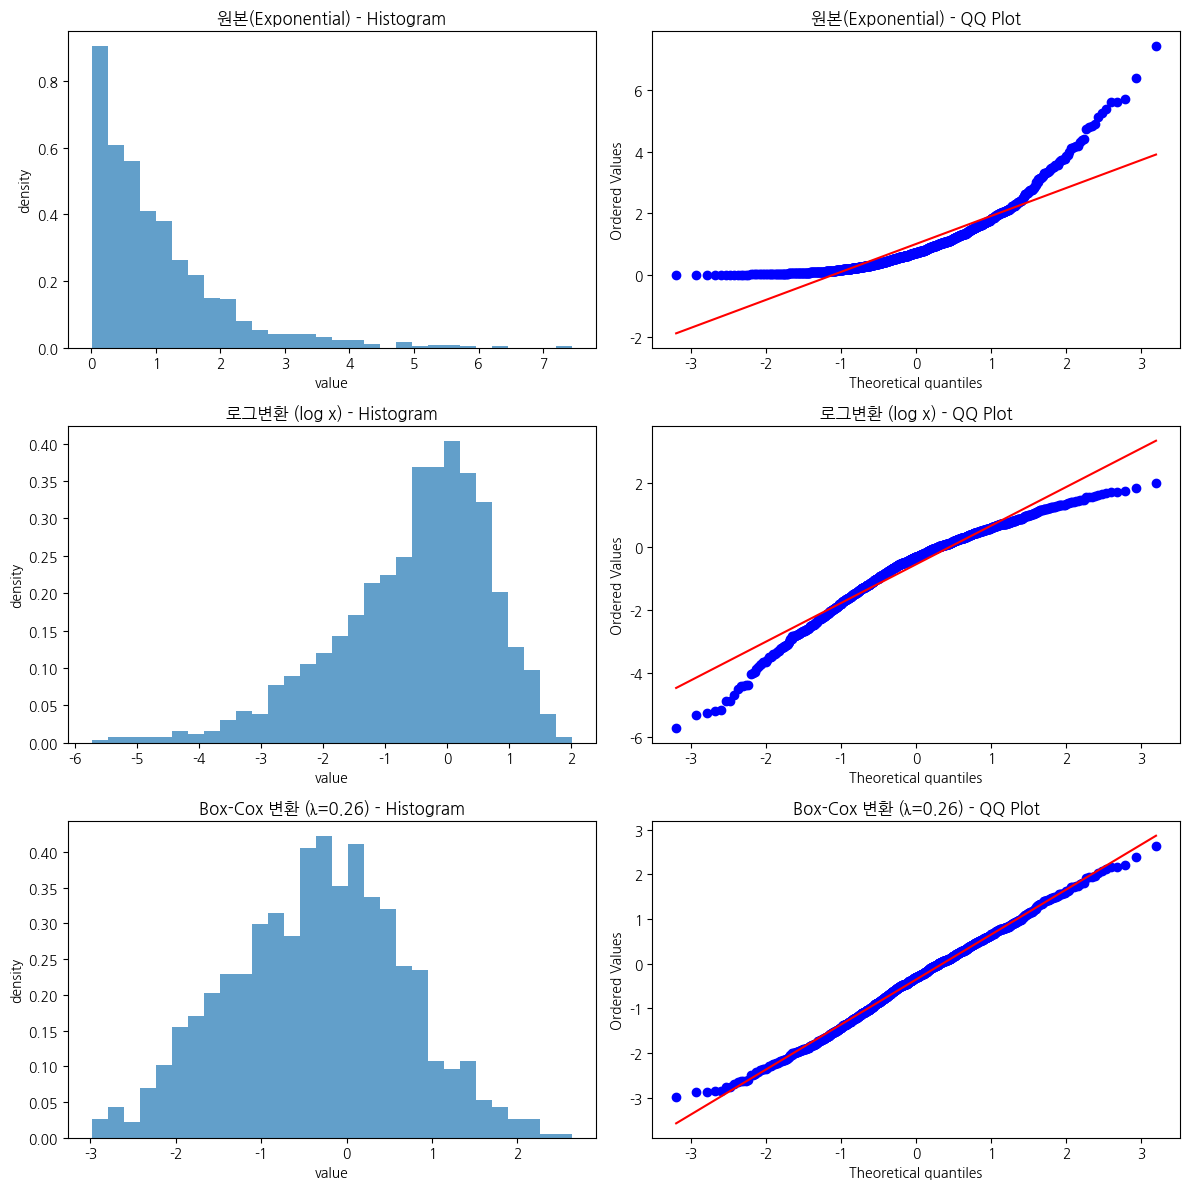

In [25]:
## =======================================================
## 시각화 : 히스토그램 + QQ Plot
## =======================================================
## QQ Plot(Quantile-Quantile Plot)
## => 데이터가 특정 분포(보통 정규분포)를 따르는지 시각적으로
## => 판단하기 위한 그래프
## ======================================================
fig, axes = plt.subplots(3,2,figsize=(12,12))

data_list = [ (sSR.values, '원본(Exponential)'),
              (x_log, '로그변환 (log x)'),
              (x_boxcox, f'Box-Cox 변환 (λ={lam:.2f})'),
              ]

for row, (data, title) in enumerate(data_list) :
    ## 히스토그램
    ax_hist= axes[row,0]
    ax_hist.hist(data,bins=30, density=True, alpha=0.7)
    ax_hist.set_title(f'{title} - Histogram')
    ax_hist.set_xlabel('value')
    ax_hist.set_ylabel('density')
    
    ## QQ Plot(정규 분포와 비교)
    ax_qq = axes[row, 1]
    probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{title} - QQ Plot')

plt.tight_layout()
plt.show()    